# Pràctica 2: Aprenentatge no supervisat

## Imports

In [1]:
# Llibreries bàsiques
import math
from collections import Counter

import numpy as np
import pandas as pd
from IPython.display import display

# Visualització
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Preprocessament
from sklearn.preprocessing import StandardScaler

# Reducció de dimensionalitat
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Mètriques per comparar els clústers amb les classes reals
from sklearn.metrics import adjusted_rand_score, confusion_matrix, normalized_mutual_info_score

# Autoencoders
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Self-Organizing Maps
from minisom import MiniSom

# Reproductibilitat
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Comprovació de la versió de PyTorch i disponibilitat de GPU
print(torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

2.12.0+cu130
CUDA disponible: False


## 1. Lectura de les dades.

In [2]:
# dades sintètiques
synthetic_original = pd.read_csv("A2-synthetic.txt", sep=",")

#dades reals
real_original = pd.read_csv("A2-real.txt", sep=";")

In [3]:
#print(synthetic_original.head())
print(synthetic_original.shape)

#print(real_original.head())
print(real_original.shape)

(360, 5)
(333, 7)


## 2. Pre-processament de les dades

In [4]:
synthetic = synthetic_original.copy()
real = real_original.copy()

Separem les variables que s’utilitzaran com a entrada de les variables auxiliars. Les etiquetes de classe no s’han d’utilitzar durant l’entrenament dels models, sinó només per visualitzar i comparar els resultats obtinguts. En el cas del dataset real, la variable Location tampoc es fa servir per entrenar, però es conserva per a la interpretació posterior dels gràfics.

In [5]:
# Synthetic
X_syn = synthetic.drop(columns=["class"])
y_syn = synthetic["class"]

# Real
X_real = real.drop(columns=["Class", "Location"])
y_real = real["Class"]
location_real = real["Location"]

In [6]:
display(y_syn.value_counts())
display(y_real.value_counts())
display(location_real.value_counts())

class
2    100
6    100
1     63
4     40
5     36
3     21
Name: count, dtype: int64

Class
C1    146
C2    119
C3     68
Name: count, dtype: int64

Location
L2    163
L3    123
L1     47
Name: count, dtype: int64

Hem comprovat la distribució de les classes en els dos datasets i de la variable Location en el dataset real. Observem que les dades no estan perfectament balancejades, ja que algunes classes tenen molts més patrons que d’altres. Això és important per interpretar els gràfics posteriorment, ja que els grups més grans poden dominar visualment els resultats, mentre que els grups més petits poden ser més difícils d’identificar.

In [7]:
scaler_syn = StandardScaler()
X_syn_scaled = scaler_syn.fit_transform(X_syn)

scaler_real = StandardScaler()
X_real_scaled = scaler_real.fit_transform(X_real)

Per finalitzar el preprocessament, estandarditzem les variables d’entrada. Aquest pas és important perquè molts dels mètodes utilitzats depenen de distàncies, variàncies o processos d’optimització, i per tant variables amb escales més grans podrien tenir un pes excessiu. Guardarem les dades ja escalades tant en format DataFrame, per conservar els noms de les variables i facilitar la visualització, com en format array, que resulta més pràctic per aplicar alguns algoritmes.

In [8]:
# Conservem les dades escalades com a DataFrame
X_syn_scaled_df = pd.DataFrame(
    X_syn_scaled,
    columns=X_syn.columns,
    index=X_syn.index
)

X_real_scaled_df = pd.DataFrame(
    X_real_scaled,
    columns=X_real.columns,
    index=X_real.index
)

# També conservem els arrays de NumPy per als algoritmes: PCA, t-SNE, k-means, AHC, autoencoder i SOM
X_syn_scaled_np = X_syn_scaled_df.values
X_real_scaled_np = X_real_scaled_df.values

# Mostrem les primeres files
display(X_syn_scaled_df.head())
display(X_real_scaled_df.head())

,x1,x2,x3,x4
0,-0.165933,-2.165686,-1.125643,-0.218701
1,-0.075211,1.121416,-0.169405,-0.207301
2,0.403832,-0.219275,0.559468,-0.413849
3,-0.194014,-0.547981,-1.391632,-0.806953
4,-0.248522,-0.225249,0.663554,-0.999257


,BL,BD,FL,BM,S
0,-1.738463,0.475587,-0.998018,-1.625681,1.009050
1,-0.950982,1.441880,-0.783651,-0.319720,-0.991031
2,0.202768,-1.355285,0.431094,1.048429,1.009050
3,-1.720150,2.001313,-0.212006,0.239977,-0.991031
4,-0.621339,0.933305,-0.140551,-0.257532,-0.991031


## 3. Aplicar sis tècniques d’aprenentatge no supervisat:


### PCA: 

La idea del PCA és reduir les dades originals a només dues components principals, conservant les direccions on les dades tenen més variància. Això permet representar dades de més dimensions en un gràfic 2D, perdent la mínima informació possible. En aquest cas, s’utilitza per visualitzar si les classes formen grups diferenciats en l’espai reduït.

In [9]:
def apply_pca(X_scaled, y, dataset_name):
    
    #mirem quantes variables té el dataset per aplicar un PCA amb tantes components com variables
    n_components = X_scaled.shape[1]
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled) #matriu amb coordenades de cada pt en l'espai PCA
    print(X_pca.shape)
    
    # Seleccionem totes les files i només les dues primeres columnes de la projecció PCA
    # corresponents a les dues primeres components principals: PC1 i PC2.
    pca_df = pd.DataFrame(
        X_pca[:, :2], 
        columns=["PC1", "PC2"],
        index=X_scaled.index if hasattr(X_scaled, "index") else None
        #conservem index si es un df, si es un array none
    )
    
    #afegim la classe real
    pca_df["class"] = y.values

    #guardem varinaça
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)

    #Projecció PCA
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue="class",
        palette="tab10",
        s=60
    )

    plt.title(f"Projecció PCA  - {dataset_name}")
    plt.xlabel(f"PC1 ({explained_variance[0]*100:.2f}% variança)")
    plt.ylabel(f"PC2 ({explained_variance[1]*100:.2f}% variança)")
    plt.legend(title="Classe")
    plt.grid(True)
    plt.show()

    # 2. Scree plot: variança acumulada en funció del nre de components
    plt.figure(figsize=(7, 5))
    plt.plot(
        range(1, n_components + 1),
        cumulative_variance,
        marker="o"
    )

    plt.title(f"Scree plot - {dataset_name}")
    plt.xlabel("Nombre de components principals")
    plt.ylabel("Variança acumulada")
    plt.xticks(range(1, n_components + 1))
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.show()

    return pca_df, pca

(360, 4)


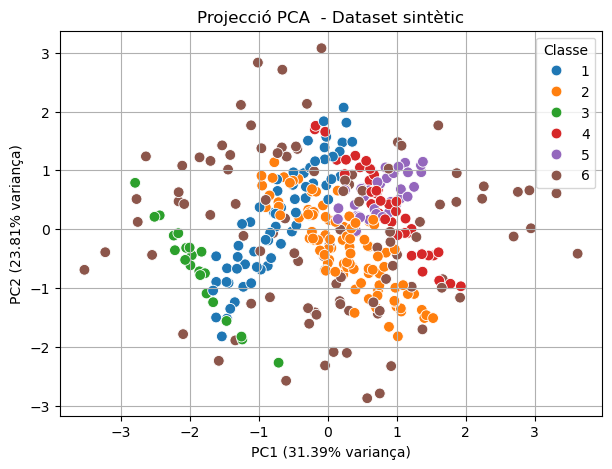

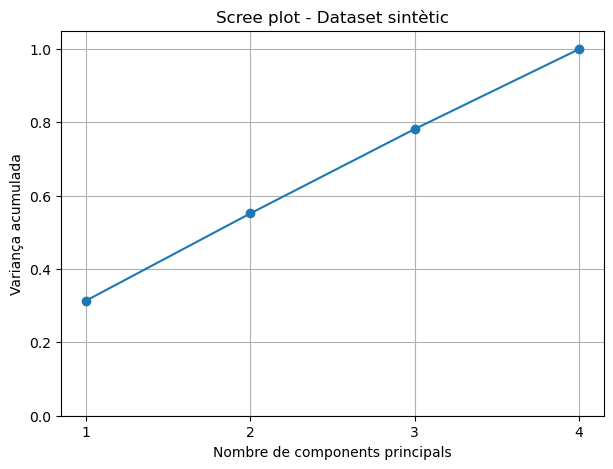

(333, 5)


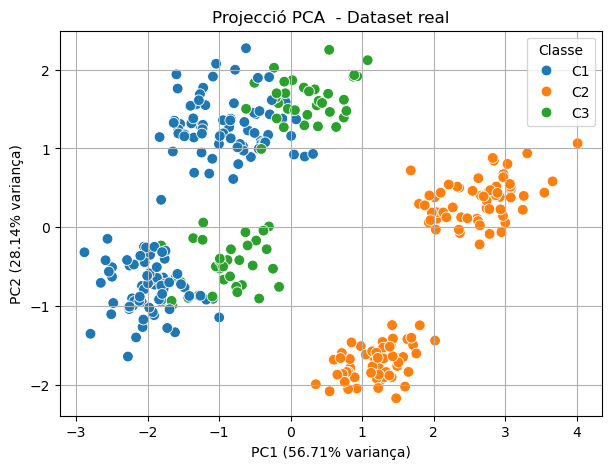

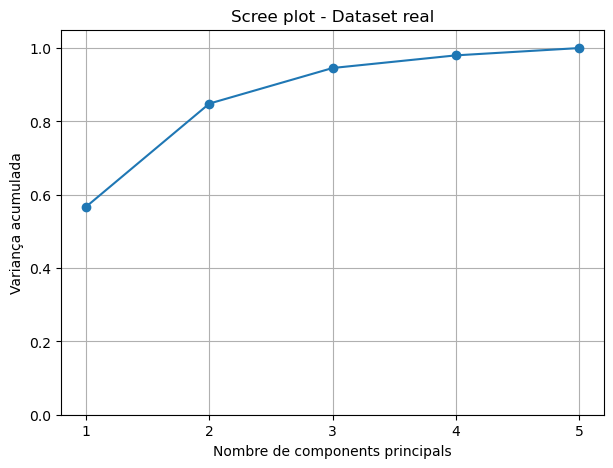

,PC1,PC2,class
0,-1.615413,-0.461632,1
1,0.499510,0.700627,5
2,0.603876,-0.296531,2
3,-0.726266,0.649637,1
4,0.633048,0.427483,4


,PC1,PC2,class
0,-2.653307,-0.704220,C1
1,-1.313026,1.563658,C1
2,1.139419,-1.578386,C2
3,-1.221611,1.771707,C1
4,-0.594826,1.229541,C1


In [10]:
# PCA per dades sintetiques
pca_syn_df, pca_syn = apply_pca(
    X_syn_scaled_df,
    y_syn,
    "Dataset sintètic"
)

# PCA per dades reals
pca_real_df, pca_real = apply_pca(
    X_real_scaled_df,
    y_real,
    "Dataset real"
)

# Show results
display(pca_syn_df.head())
display(pca_real_df.head())

#### Conclusions PCA

En el dataset sintètic, la projecció PCA mostra un solapament important entre les classes. Això és coherent amb el scree plot, ja que les dues primeres components principals només acumulen aproximadament un 60% de la variància total. Per tant, en reduir les dades a dues dimensions es perd una part rellevant de la informació, i és possible que part de la separació entre classes quedi en components posteriors.

En canvi, en el dataset real s’observa una separació més clara entre les classes, especialment per a la classe C2. En aquest cas, les dues primeres components principals acumulen aproximadament un 85% de la variància total, de manera que la representació en dues dimensions conserva gran part de la informació original. Això fa que el PCA sigui més adequat per visualitzar l’estructura del dataset real que la del dataset sintètic.

### t-SNE


El t-SNE (t-distributed Stochastic Neighbor Embedding) és un mètode que es fa servir principalment per visualització i es basa en el fet que els objectes similars en l'espai original han de quedar a prop també en l'espai projectat. Per a això, modela les distàncies entre punts en l'espai original amb distribucions gaussianes, modela les distàncies en l'espai projectat amb una distribució t de Student, i minimitza la divergència KL (Kullback–Leibler) entre totes dues distribucions. A més, el paràmetre perplexity representa aproximadament el nombre efectiu de veïns que l'algorisme té en compte.

In [11]:
def apply_tsne(X_scaled, y, dataset_name, perplexities=[5, 10, 30, 50]):
  #valors perplexity de prova: nombre efectiu de veïns
    
    tsne_results = {} #creem diccionari

    n_samples = X_scaled.shape[0]  #nre de patrons

    perplexities = list(perplexities)

    n_rows = 2
    n_cols = int(np.ceil(len(perplexities) / n_rows))

    # Creem una figura amb dues files de gràfiques perquè no quedin massa petites
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = axes.flatten()

    plot_idx = 0

    for perplexity in perplexities:

        if perplexity >= n_samples:
            print(f"No s'aplica t-SNE amb perplexity={perplexity}, perquè ha de ser menor que n_samples={n_samples}")
        else:
            tsne = TSNE(
                n_components=2, #volem reduir a 2 dimensions
                perplexity=perplexity,
                learning_rate="auto",
                init="pca", # Inicialitzem t-SNE amb PCA perquè el resultat sigui més estable que amb una inicialització aleatòria
                random_state=RANDOM_STATE
            )

            X_tsne = tsne.fit_transform(X_scaled)

            tsne_df = pd.DataFrame(
                X_tsne,
                columns=["tSNE1", "tSNE2"],
                index=X_scaled.index if hasattr(X_scaled, "index") else None
                #conservem index si es un df, si es un array none
            )

            tsne_df["class"] = y.values
            tsne_results[perplexity] = tsne_df
            #guardem dataframe al diccionari amb el valor de perplexity com clau

            ax = axes[plot_idx]

            sns.scatterplot(
                data=tsne_df,
                x="tSNE1",
                y="tSNE2",
                hue="class",
                palette="tab10",
                s=60,
                ax=ax
            )

            ax.set_title(f"Projecció t-SNE - {dataset_name} - perplexity={perplexity}")
            ax.set_xlabel("t-SNE 1")
            ax.set_ylabel("t-SNE 2")
            ax.legend(title="Classe")
            ax.grid(True)

            plot_idx += 1

    # Amaguem els subplots buits si el nombre de valors de perplexity no omple tota la graella
    for j in range(plot_idx, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    return tsne_results

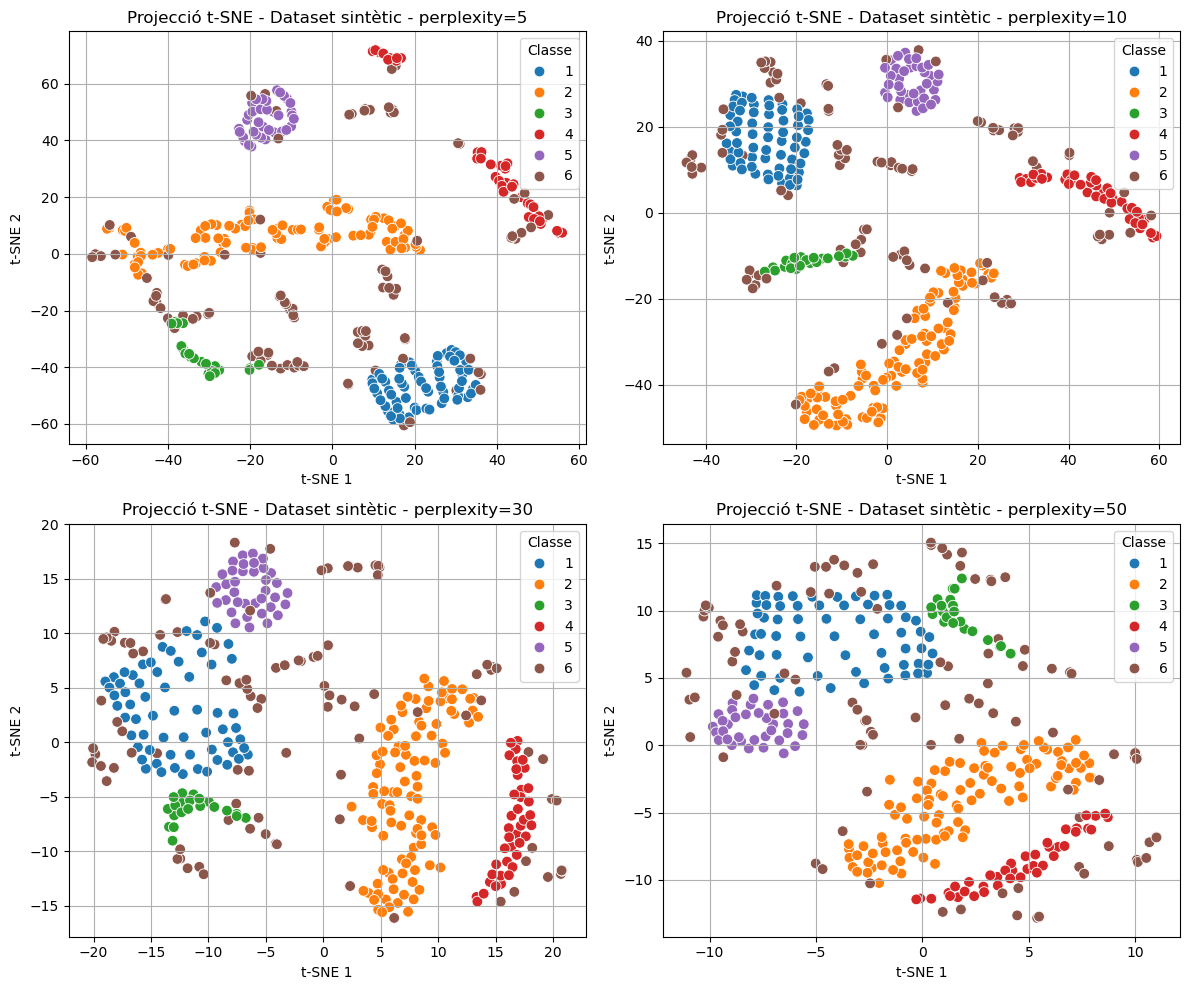

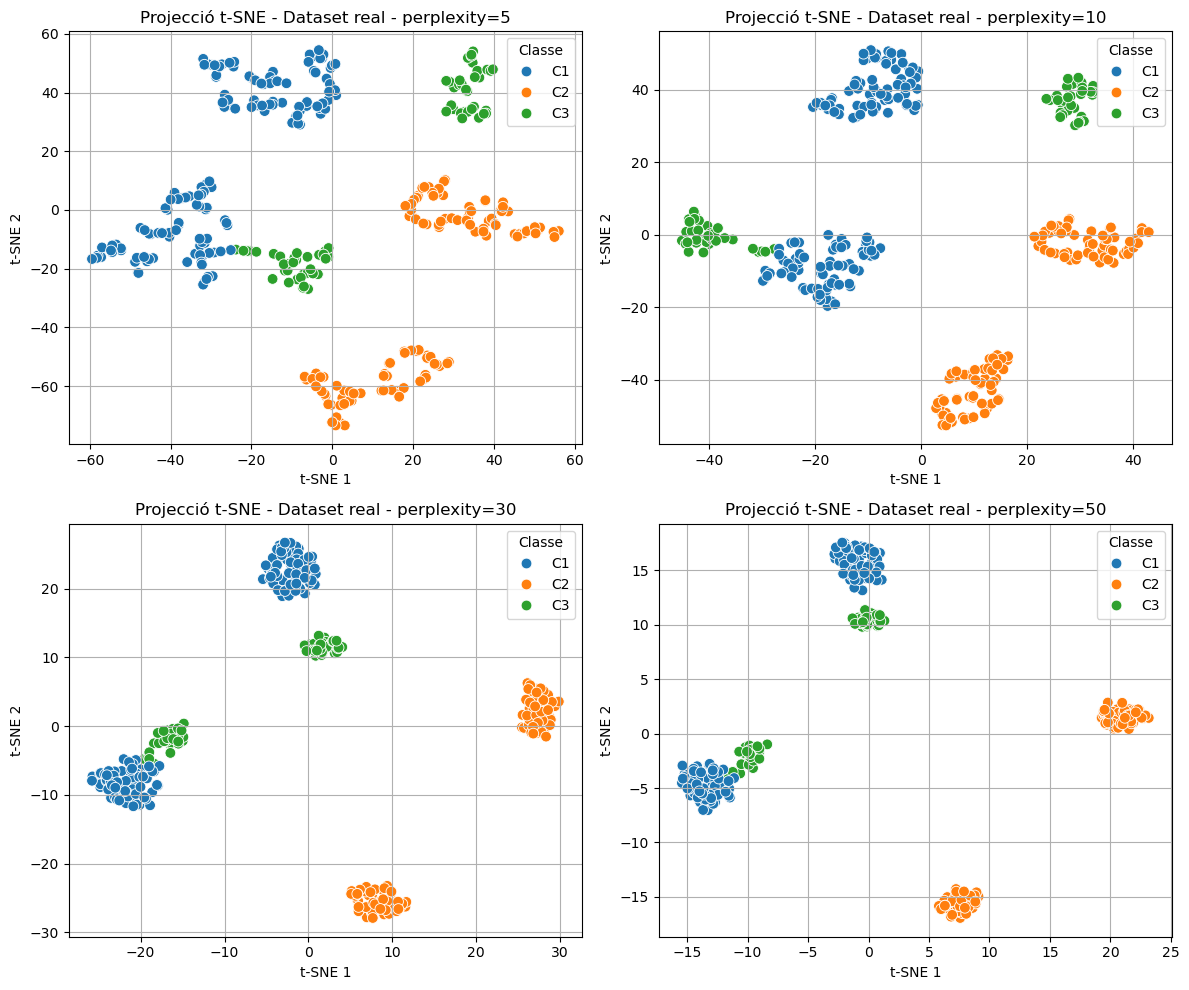

,tSNE1,tSNE2,class
0,-23.529404,-10.444178,C1
1,-4.385883,22.853743,C1
2,9.032087,-27.406357,C2
3,-5.420836,21.394278,C1
4,-1.218725,21.740320,C1


In [12]:
tsne_syn_results = apply_tsne(
    X_syn_scaled_df,
    y_syn,
    "Dataset sintètic",
    perplexities=[5, 10, 30, 50]
)

tsne_real_results = apply_tsne(
    X_real_scaled_df,
    y_real,
    "Dataset real",
    perplexities=[5, 10, 30, 50]
)

tsne_syn_results[30].head()
tsne_real_results[30].head()

#### Conclusions t-SNE

A diferència del PCA, el t-SNE no calcula directament una projecció lineal fixa. Primer col·loca els punts en un espai 2D i, a partir d'aquesta configuració inicial, els va movent de manera iterativa. L'objectiu d'aquest procés és que els punts que eren propers o similars en l'espai original acabin quedant també propers en la representació 2D. Per això, el resultat final pot mostrar agrupacions o separacions entre classes que no serien tan evidents amb una projecció lineal.

En el conjunt de dades sintètic, algunes classes, com ara la 1, 4 i 5, formen grups compactes mentre que altres apareixen més disperses. Concretament, la classe 6 queda repartida per diferents zones de la representació, cosa que indica que els seus patrons poden ser més heterogenis o estar més propers a altres classes en l'espai original. El valor de perplexity afecta bastant: amb valors baixos apareixen grups més petits i separats, mentre que amb valors més alts l'estructura és més global.

En el conjunt de dades real, la separació entre classes és més clara. Les classes C1, C2 i C3 apareixen bastant diferenciades, especialment per valors de perplexity iguals a 30 i 50. Algunes classes es divideixen en més d'un grup, com C1 i C2, fet que pot indicar que dins d'una mateixa classe hi ha subestructures internes o patrons amb característiques diferents.



Cal recordar que els eixos t-SNE 1 i t-SNE 2 no tenen una interpretació directa. L'important és la proximitat relativa entre punts i la formació de grups. Per tant, el t-SNE és útil per visualitzar l'estructura de les dades i detectar possibles agrupacions.

### K-means

El k-means és un mètode fer clustering, és a dir, per agrupar patrons similars dins d'un mateix grup. 

La idea principal és fixar un nombre de clústers \(k\) i representar cada clúster mitjançant un centroide. Inicialment, aquests centroides es col·loquen en diferents posicions i, de manera iterativa, cada patró s'assigna al centroide més proper. Després, els centroides es recalculen com la mitjana dels punts assignats a cada clúster. Aquest procés es repeteix fins que les assignacions ja no canvien de manera significativa.

En aquesta pràctica s'aplica k-means per a diferents valors de \(k\), i els clústers obtinguts es comparen amb les classes reals. Les classes reals no s'utilitzen per entrenar el model, sinó només per interpretar si els grups trobats per l'algorisme tenen relació amb l'estructura real de les dades.

Per fer aquesta comparació s'utilitzen dues mètriques: l'ARI (Adjusted Rand Index) i l'NMI (Normalized Mutual Information). L'ARI mesura fins a quin punt les assignacions dels clústers coincideixen amb les classes reals, corregint l'efecte de possibles coincidències aleatòries. L'NMI mesura la informació compartida entre els clústers obtinguts i les classes reals. En tots dos casos, valors més alts indiquen una millor correspondència entre els clústers trobats i les classes reals.

In [13]:
def apply_kmeans(X_scaled, pca_df, y_true, dataset_name, k_values):

    results = []
    kmeans_results = {}
    #diccionari on es guardaran les etiquetes de cluster obtingudes per cada valor de k

    k_values = list(k_values)

    n_rows = 2
    n_cols = int(np.ceil(len(k_values) / n_rows))

    # Creem una figura amb dues files de gràfiques perquè no quedin massa petites
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

    axes = axes.flatten()

    for i, k in enumerate(k_values):

        kmeans = KMeans(
            n_clusters=k, #Indica quants clústers volem trobar, canvia en cada iteració del bucle.
            random_state=RANDOM_STATE,
            n_init=10 ## Executem k-means 10 vegades amb inicialitzacions diferents i ens quedem amb la millor solució
        )

        #Entrenem k-means i assignem a cada patró el clúster corresponent
        cluster_labels = kmeans.fit_predict(X_scaled)

        kmeans_results[k] = cluster_labels

        #Calculem l'ARI per comparar els clústers obtinguts amb les classes reals
        ari = adjusted_rand_score(y_true, cluster_labels)

        #Avaluem fins a quin punt els clústers trobats per k-means coincideixen amb les classes reals
        nmi = normalized_mutual_info_score(y_true, cluster_labels)

        results.append({
            "k": k,
            "ARI": ari,
            "NMI": nmi,
            "Inertia": kmeans.inertia_   #La inèrcia suma les distàncies quadràtiques dels punts al seu centroide més proper
        })

        plot_df = pca_df[["PC1", "PC2"]].copy()
        plot_df["cluster"] = cluster_labels
        plot_df["real_class"] = y_true.values

        ax = axes[i]

        sns.scatterplot(
            data=plot_df,
            x="PC1",
            y="PC2",
            hue="cluster",
            palette="tab10",
            s=60,
            ax=ax
        )

        ax.set_title(f"Clustering amb k-means - {dataset_name} - k={k}")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.legend(title="Clúster")
        ax.grid(True)

    # Amaguem els subplots buits si el nombre de valors de k no omple tota la graella
    for j in range(len(k_values), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    results_df = pd.DataFrame(results)

    return results_df, kmeans_results

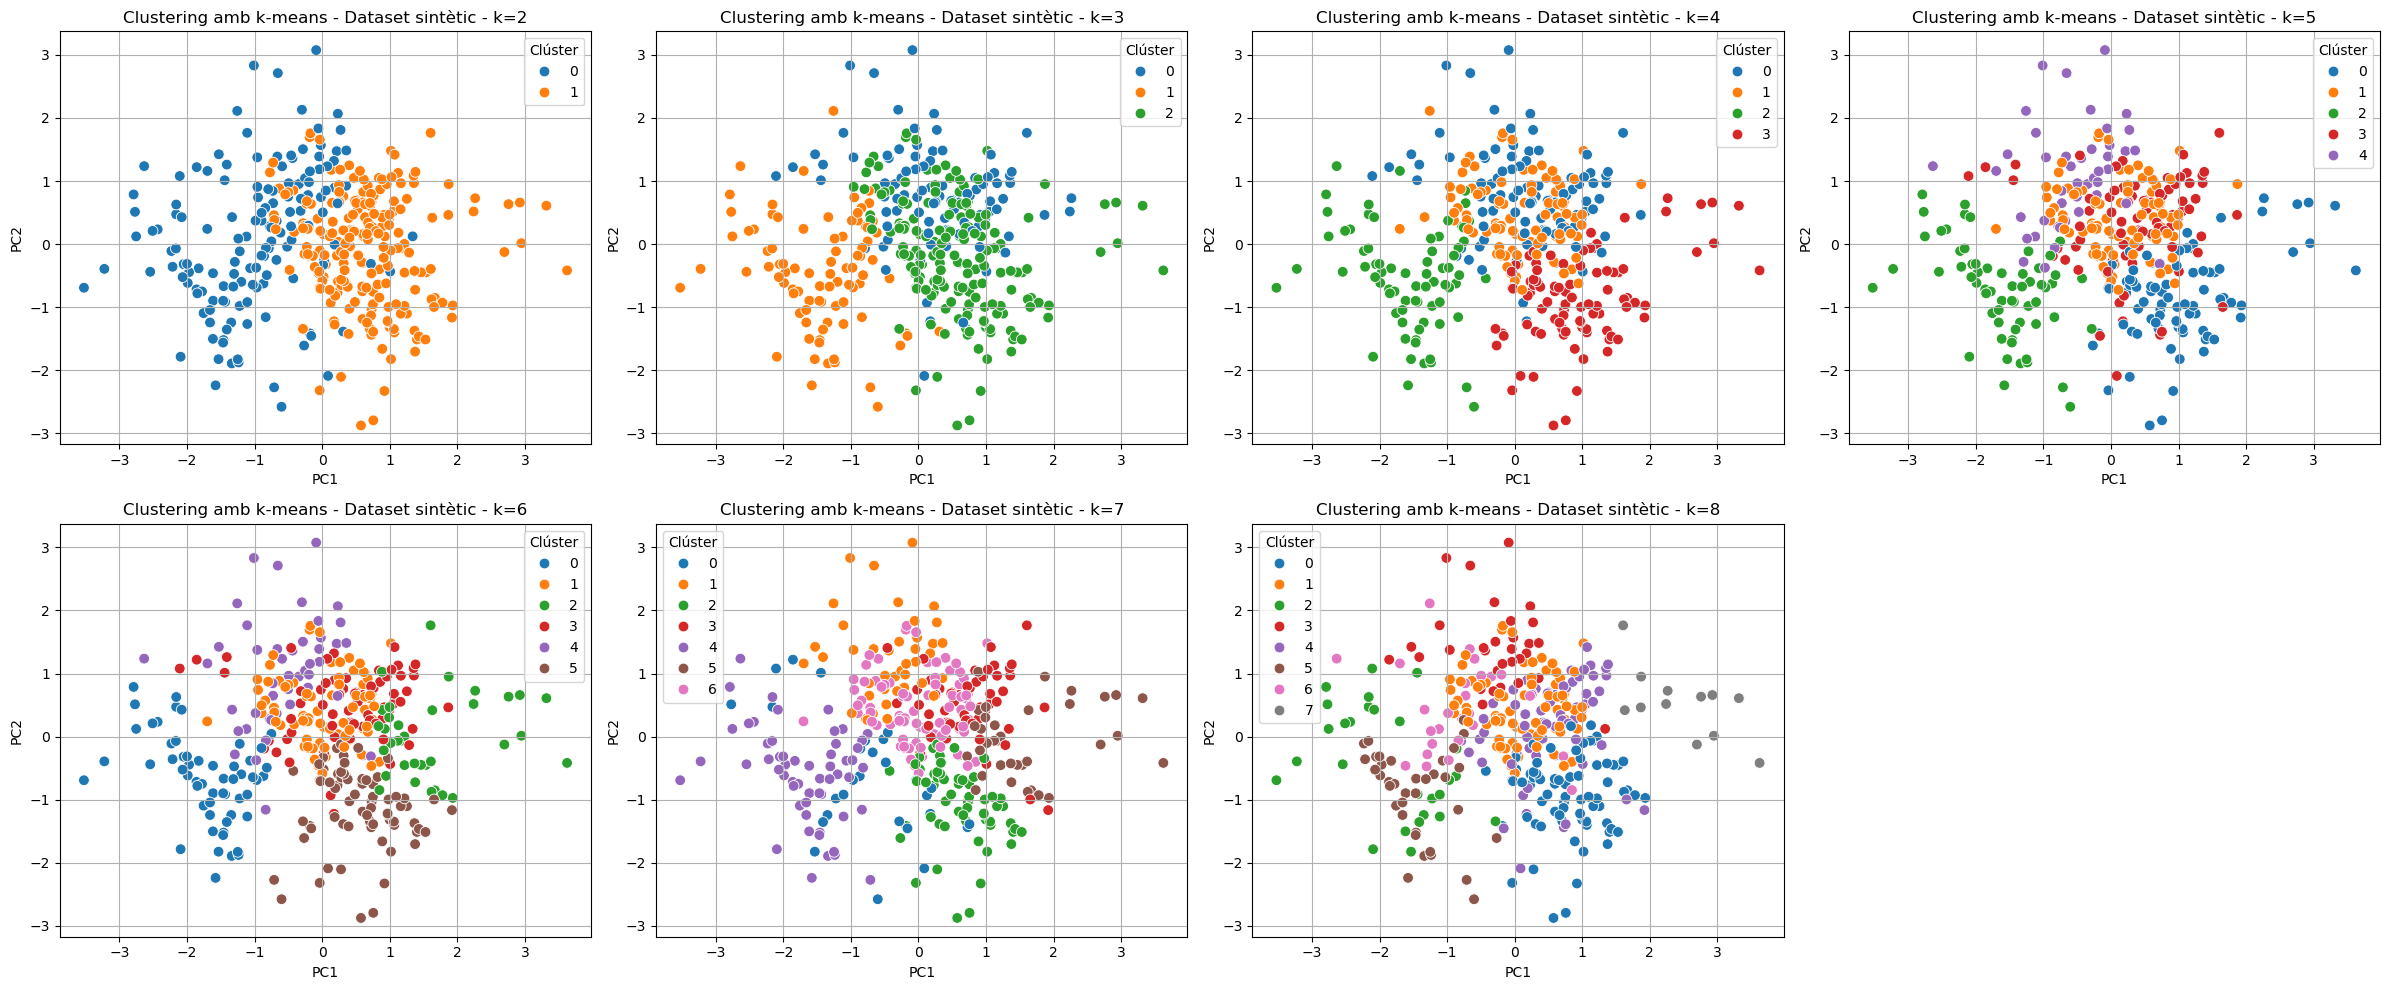

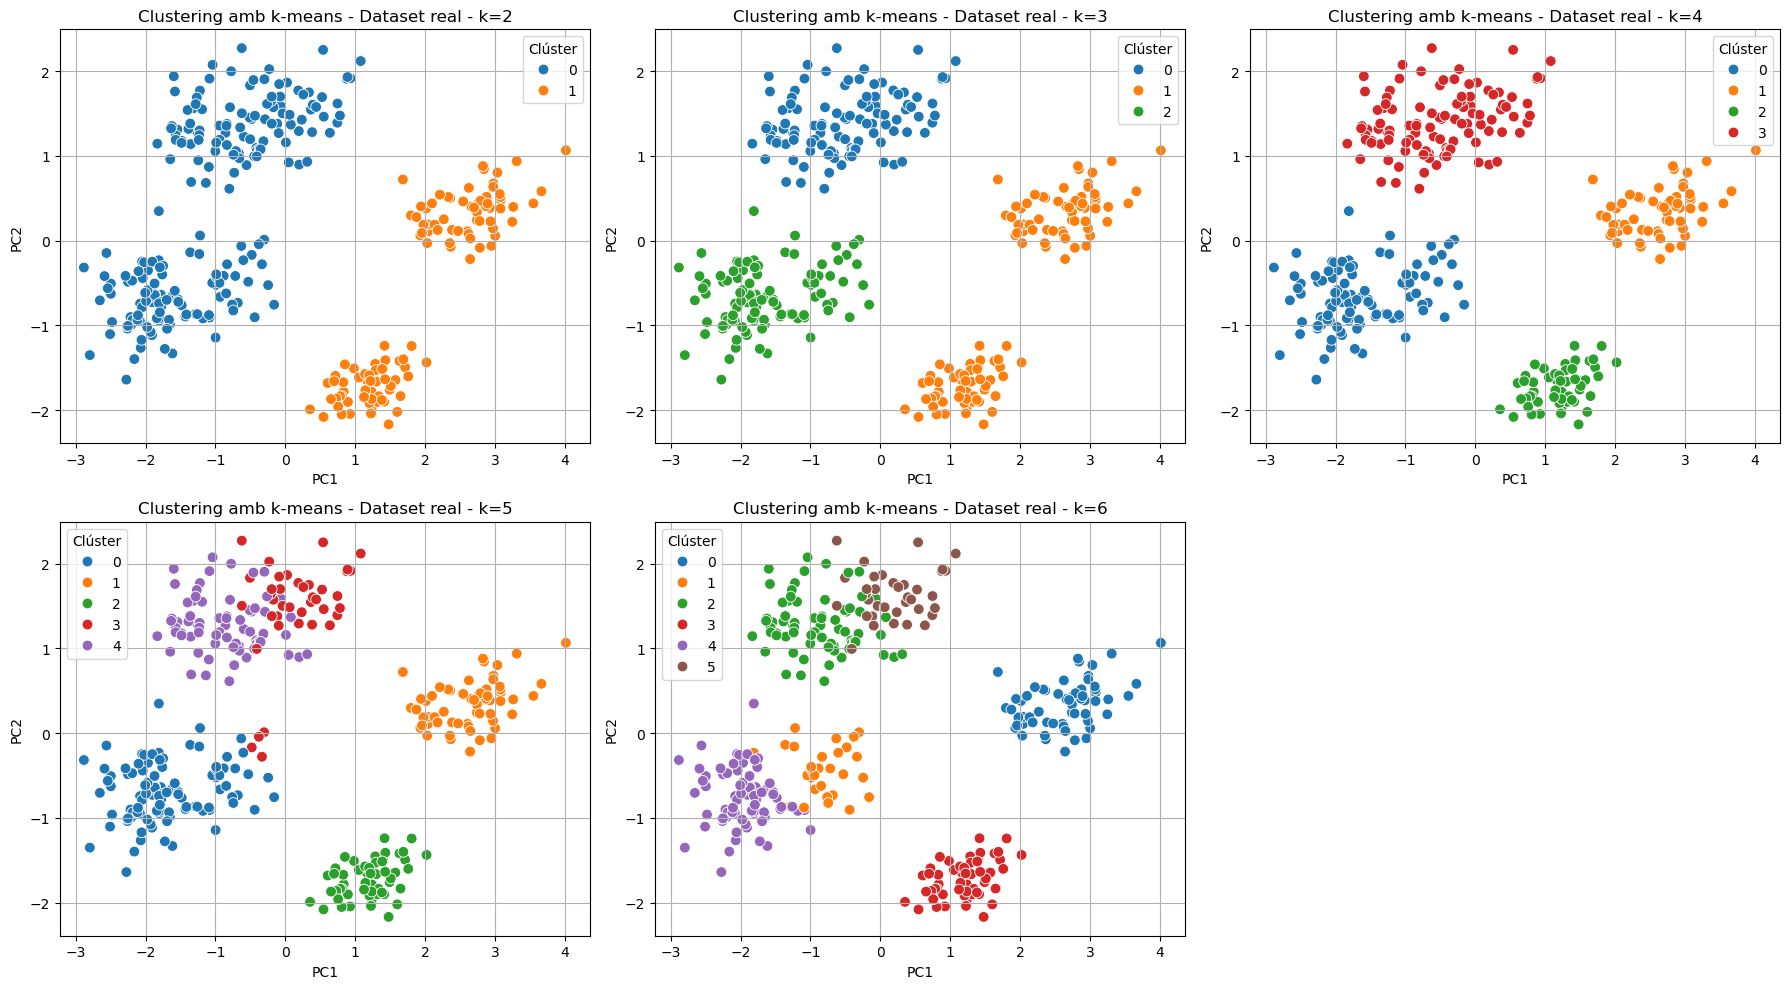

In [14]:
k_values_syn = range(2, 9)

kmeans_syn_results_df, kmeans_syn_results = apply_kmeans(
    X_syn_scaled_df,
    pca_syn_df,
    y_syn,
    "Dataset sintètic",
    k_values_syn
)


k_values_real = range(2, 7)

kmeans_real_results_df, kmeans_real_results = apply_kmeans(
    X_real_scaled_df,
    pca_real_df,
    y_real,
    "Dataset real",
    k_values_real
)

#### Conclusions k-means

En el dataset sintètic, els clústers obtinguts amb k-means no separen de manera gaire clara l'estructura de les dades. Per valors baixos de k, com k=2o k=3, l'algorisme divideix les dades en zones bastant generals, però encara hi ha molta barreja. Quan s'augmenta k, apareixen clústers més petits, però això no implica necessàriament una millor correspondència, ja que alguns grups fragmenten regions que ja estaven barrejades.

En el dataset real, la separació és molt més clara. Amb k=2, k-means ja distingeix dos grans blocs de punts, però encara agrupa classes que visualment semblen diferents. Amb k=3 i k=4, els clústers obtinguts s'ajusten millor a l'estructura principal de les dades, ja que apareixen grups força diferenciats. En canvi, per valors més alts de k, l'algorisme comença a dividir grups que ja eren compactes en subgrups més petits.

Per tant, visualment, el dataset real presenta una estructura més adequada per a k-means que el dataset sintètic. En particular, \(k=3\) sembla una bona elecció per al dataset real, mentre que en el dataset sintètic la separació és menys evident i l'augment de \(k\) no millora clarament la interpretació.

#### Comparació amb les classes reals

In [15]:
def plot_kmeans_scores(results_df, dataset_name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(results_df["k"], results_df["ARI"], marker="o", label="ARI")
    ax.plot(results_df["k"], results_df["NMI"], marker="o", label="NMI")

    ax.set_title(f"Comparació k-means amb classes reals - {dataset_name}")
    ax.set_xlabel("Nombre de clústers k")
    ax.set_ylabel("Score")
    ax.set_xticks(results_df["k"])
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True)

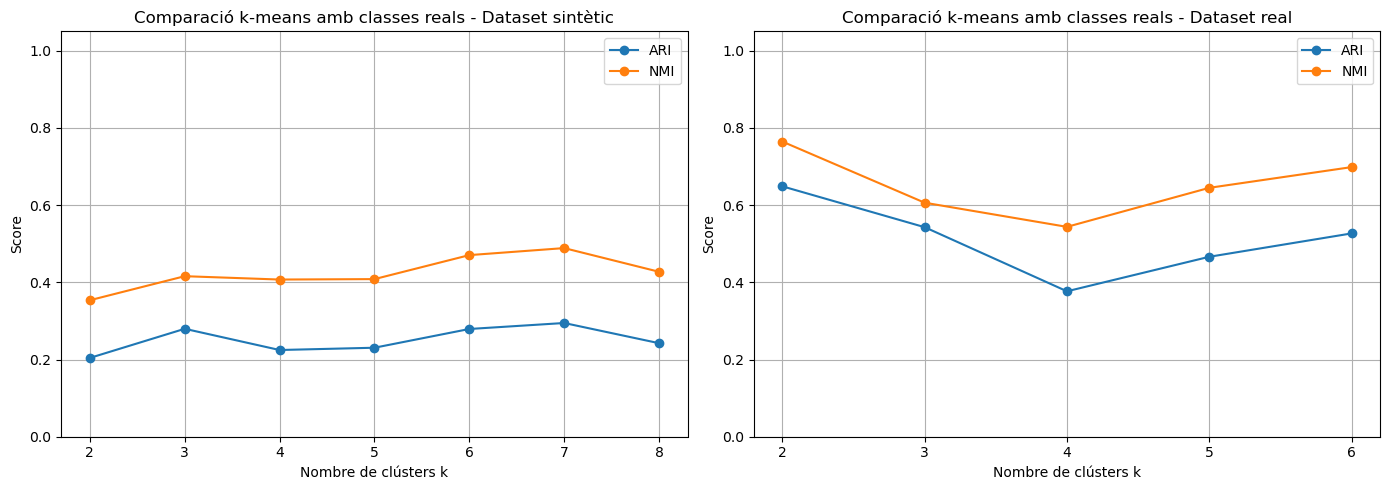

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_kmeans_scores(kmeans_syn_results_df, "Dataset sintètic", ax=axes[0])
plot_kmeans_scores(kmeans_real_results_df, "Dataset real", ax=axes[1])

plt.tight_layout()
plt.show()

S'han calculat dues mètriques per comparar els grups obtinguts amb les classes reals: l'ARI i l'NMI. Aquestes mesuren si les assignacions de k-means coincideixen amb les etiquetes reals del dataset.

En el dataset sintètic, els valors d'ARI i NMI són baixos per a tots els valors de k. Això indica que els clústers trobats per k-means no coincideixen gaire amb les classes reals. Tot i que alguns valors, com k=6 o k=7, milloren lleugerament les mètriques, la correspondència continua sent limitada. Per tant, el dataset sintètic no presenta una estructura clarament adequada per ser separada amb k-means.

En el dataset real, els valors d'ARI i NMI són més alts que en el sintètic, cosa que confirma que la seva estructura és més coherent amb els clústers trobats. Les mètriques són màximes per k=2, encara que el dataset tingui tres classes reals. Això pot passar perquè k-means detecta molt bé dos grans blocs principals de dades. Quan s'augmenta k, l'algorisme pot separar millor algunes subestructures visuals, però també pot dividir una mateixa classe real en diversos clústers, fet que redueix l'ARI i l'NMI.

Finalment, k=4 pot semblar visualment una bona opció perquè genera grups compactes i ben separats, però les mètriques indiquen que aquesta partició no coincideix tan bé amb les classes reals. 

### AHC

Aquest mètode de clustering jeràrquic que permet estudiar l’estructura de les dades a diferents nivells d’agrupació. El mètode comença considerant cada patró com un clúster independent. A cada pas, es busquen els dos clústers més propers segons la distància euclidiana i el criteri d’enllaç escollit, i es fusionen en un únic clúster. Aquest procés es repeteix fins que tots els patrons queden agrupats dins d’una mateixa estructura jeràrquica.

S’han comparat dos criteris d’enllaç diferents: UPGMA (unweighted average linkage) i complete linkage. En el primer cas, la distància entre dos clústers es calcula a partir de la distància mitjana entre els seus punts, mentre que en el segon cas es considera la distància màxima entre punts de clústers diferents. 

Representarem els resultats mitjançant dendrogrames, que mostren l'estructura jeràrquica obtinguda amb AHC a partir de la matriu de distàncies euclidianes. Cada fulla representa un patró del dataset i el color de l'etiqueta indica la seva classe real. Aquesta classe no s'utilitzarà durant l'aprenentatge, sinó només per interpretar visualment si els agrupaments obtinguts coincideixen amb les classes originals.

In [17]:
def apply_ahc_dendrograms(X_scaled, y, dataset_name):

    # Reiniciem l'índex de les classes per poder accedir-hi correctament amb iloc
    y = pd.Series(y).reset_index(drop=True)

    # Calculem les distàncies euclidianes entre tots els parells de patrons en format comprimit
    distance_matrix = pdist(X_scaled, metric="euclidean")

    # Assigna un color a cada classe real, només per a la visualització
    classes = sorted(y.unique())
    palette = sns.color_palette("tab10", n_colors=len(classes))
    class_to_color = {cls: palette[i] for i, cls in enumerate(classes)}

    # mètodes que ens demanen
    methods = {
        "UPGMA / average linkage": "average",
        "Complete linkage": "complete"
    }

    linkage_results = {}

    for title, method in methods.items():

        # Calculem l'agrupament jeràrquic fusionant progressivament els clústers segons el criteri d'enllaç escollit
        Z = linkage(
            distance_matrix,
            method=method,
            optimal_ordering=True
        )

        linkage_results[method] = Z

        plt.figure(figsize=(18, 7))
        ax = plt.gca()

        dendro = dendrogram(
            Z,
            labels=[str(cls) for cls in y],
            leaf_rotation=90,
            leaf_font_size=6,
            color_threshold=0,
            above_threshold_color="black",
            ax=ax
        )

        # Pintem cada etiqueta de les fulles segons la seva classe real
        for tick_label, leaf_index in zip(ax.get_xmajorticklabels(), dendro["leaves"]):
            real_class = y.iloc[leaf_index]
            tick_label.set_color(class_to_color[real_class])

        # Llegenda
        legend_elements = [
            Line2D(
                [0], [0],
                marker="o",
                color="w",
                label=f"Class {cls}",
                markerfacecolor=class_to_color[cls],
                markersize=8
            )
            for cls in classes
        ]

        ax.legend(
            handles=legend_elements,
            title="Real class",
            loc="upper right"
        )

        plt.title(f"Dendrograma AHC - {title} - {dataset_name}")
        plt.xlabel("Patrons / classe real")
        plt.ylabel("Distancia Euclidiana")
        plt.tight_layout()
        plt.show()

    return linkage_results

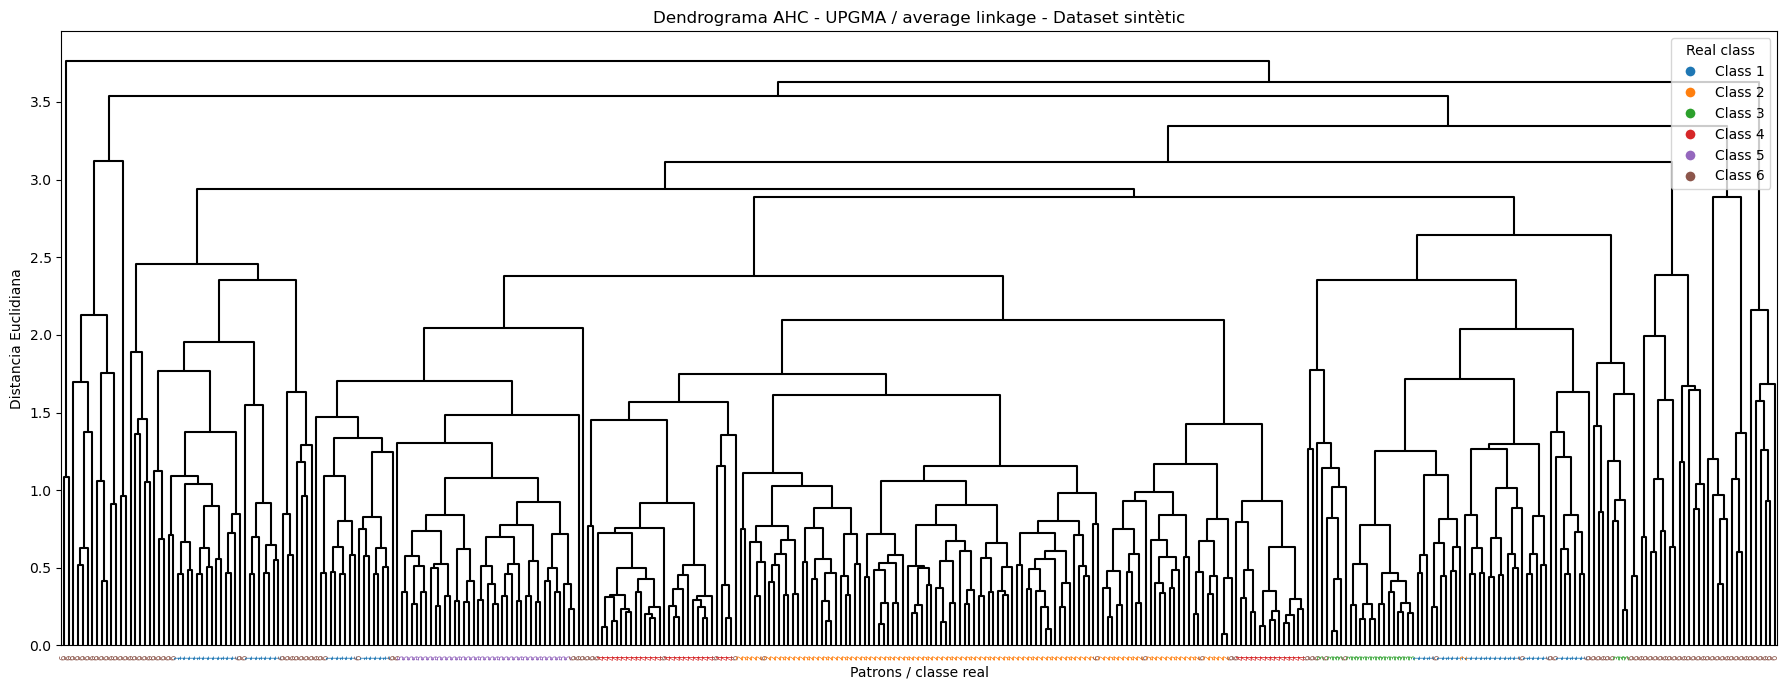

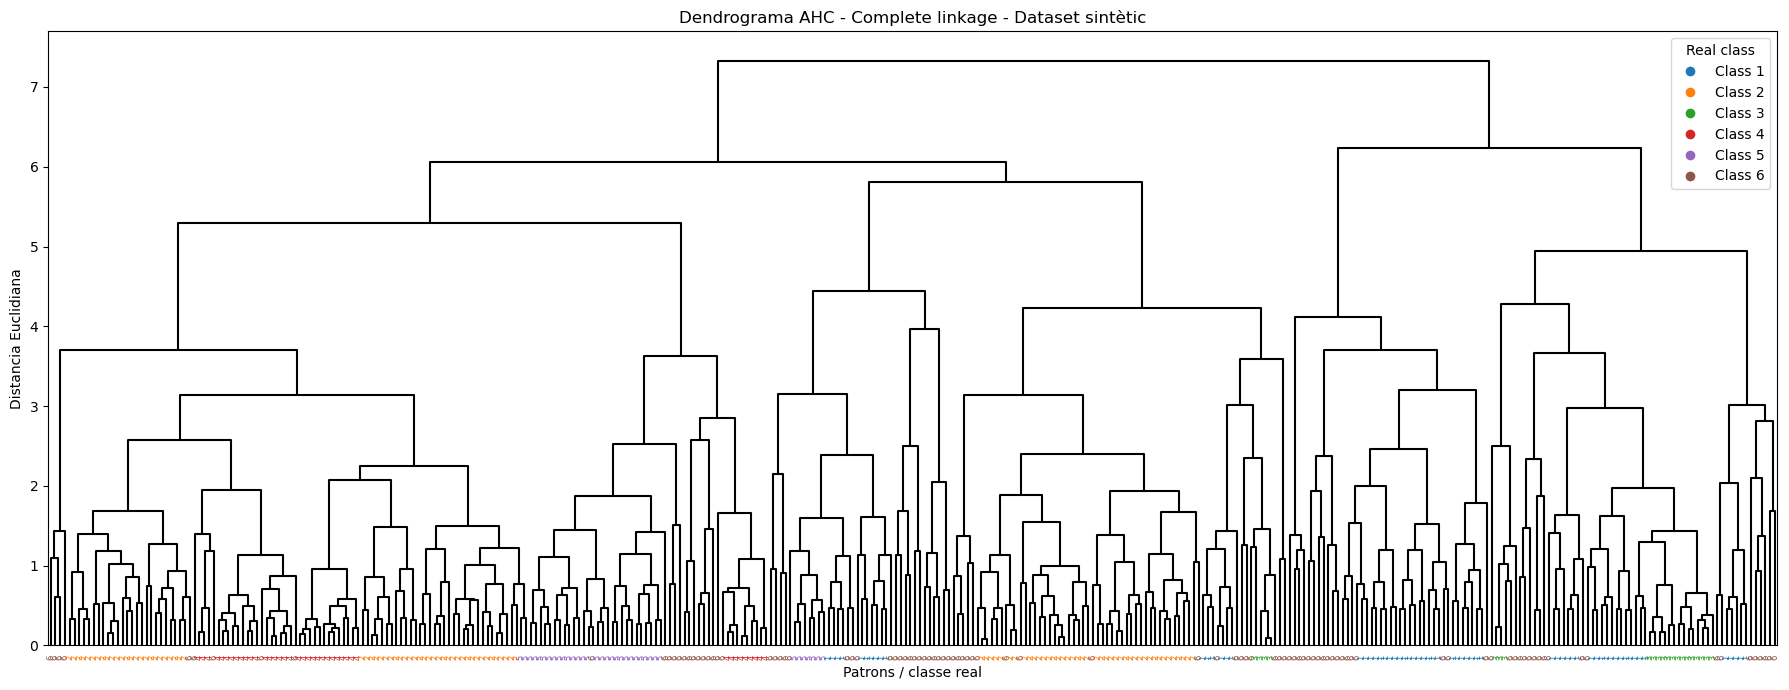

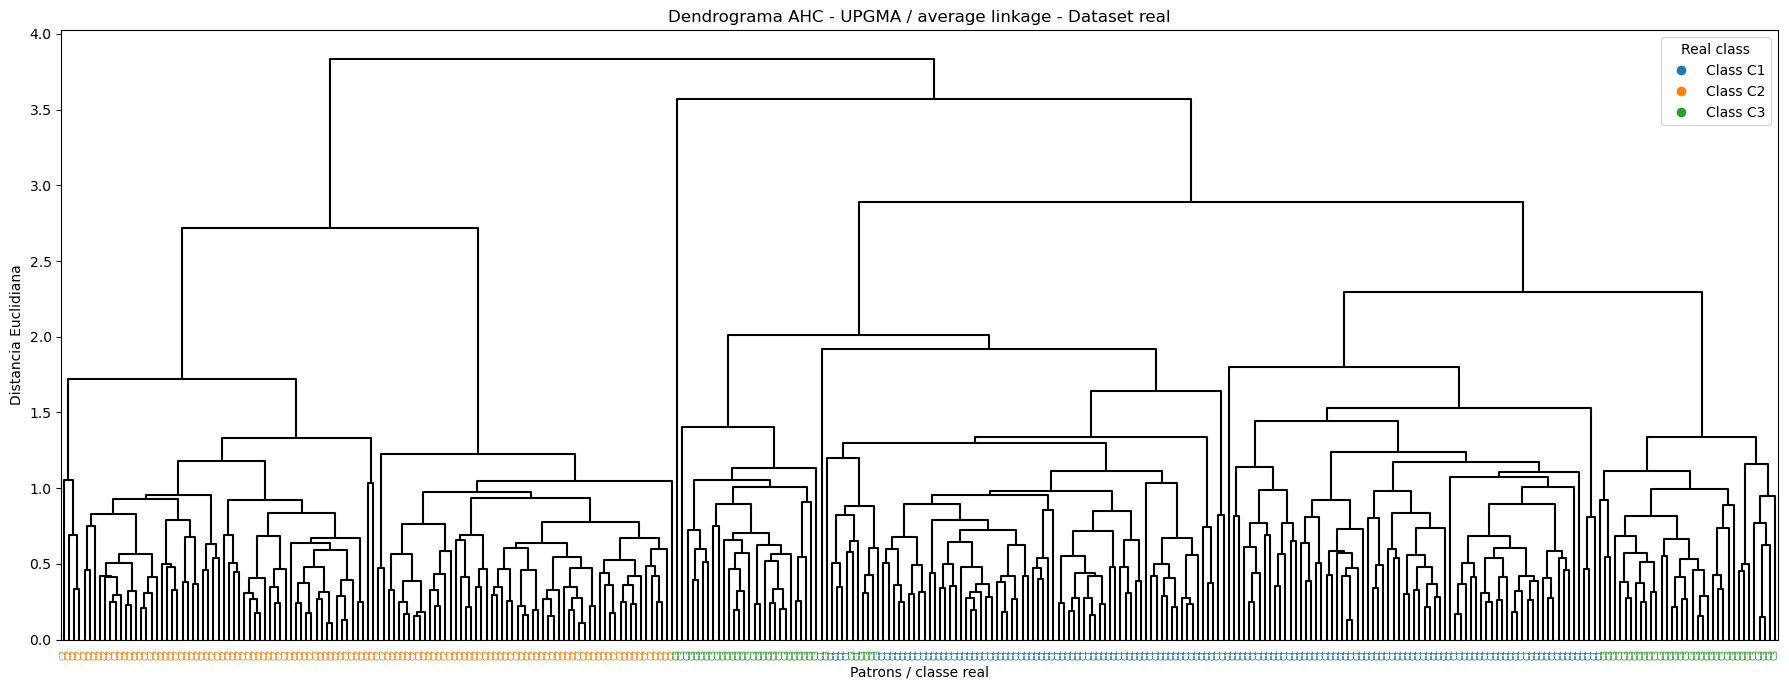

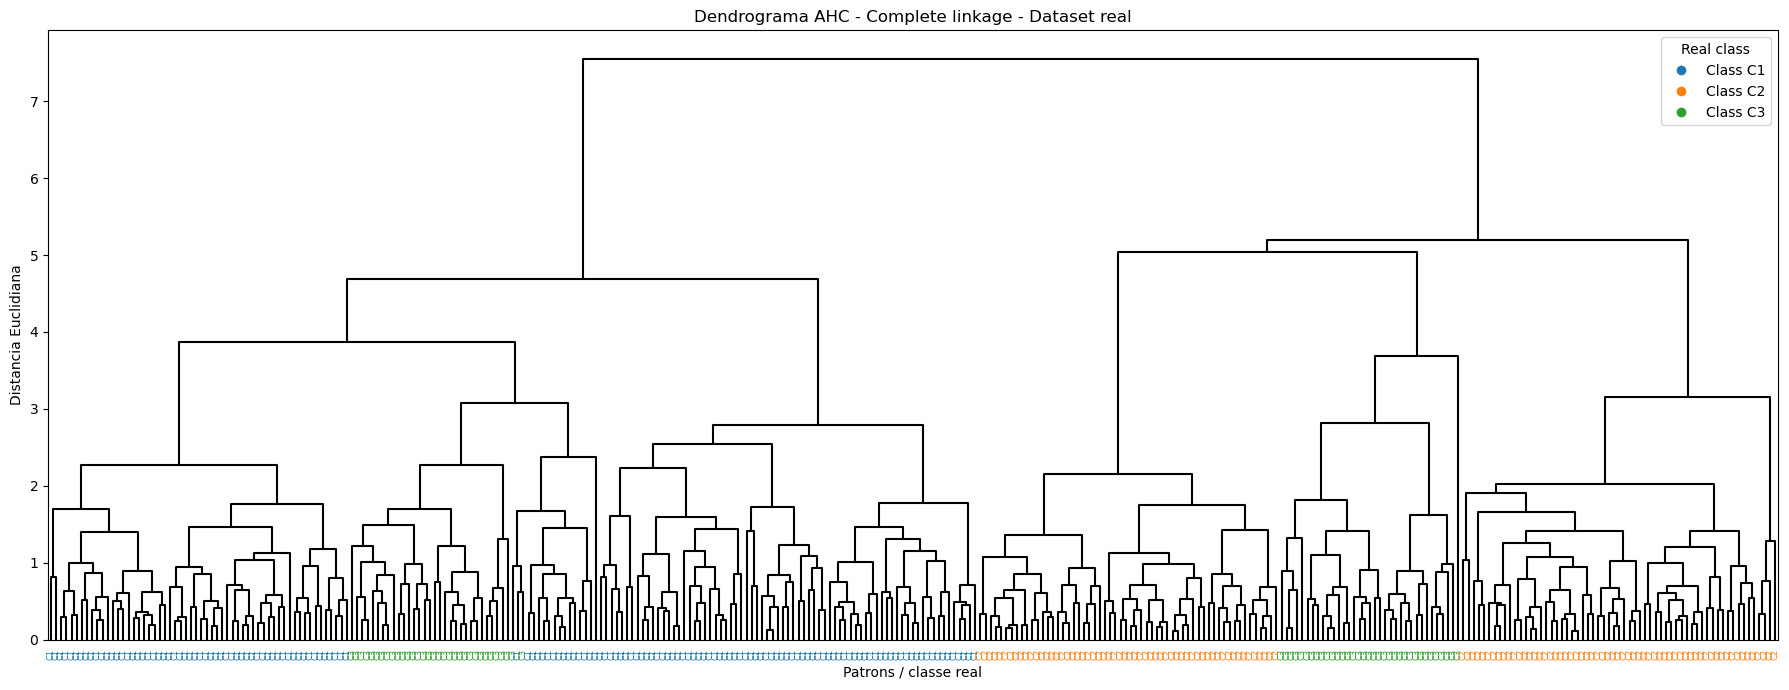

In [18]:
ahc_syn_results = apply_ahc_dendrograms(
    X_syn_scaled_df,
    y_syn,
    "Dataset sintètic"
)

ahc_real_results = apply_ahc_dendrograms(
    X_real_scaled_df,
    y_real,
    "Dataset real"
)

#### Conclusions AHC

En el dataset sintètic, els resultats mostren una certa agrupació local de patrons de la mateixa classe, però també es veu una barreja important de colors al llarg del dendrograma. Això indica que el mètode no separa perfectament les sis classes reals. Per tant, tot i que AHC identifica grups de patrons propers, aquests grups no coincideixen completament amb les etiquetes originals.

Comparant els dos criteris d'enllaç, UPGMA / average linkage genera una estructura més gradual, ja que fusiona clústers segons una distància mitjana entre els seus punts. En canvi, complete linkage produeix unions a distàncies més altes i tendeix a formar clústers més compactes, perquè considera la distància màxima entre punts de clústers diferents. Tot i aquesta diferència, en el dataset sintètic cap dels dos criteris aconsegueix una separació clara de totes les classes.

En el dataset real, la separació visual és una mica més clara. Es poden observar zoneson predomina una mateixa classe, fet que indica que les dades tenen una estructura més relacionada amb les etiquetes reals. Tot i això, també apareixen classes barrejades en diverses branques, de manera que la correspondència entre els clústers jeràrquics i les classes reals no és perfecta.

En conclusió, AHC és útil per visualitzar com es van agrupant progressivament els patrons.

### Autoencoder

En aquest apartat s’utilitza un autoencoder per obtenir una projecció de les dades en dues dimensions. A diferència de PCA, que fa una reducció lineal, l’autoencoder és una xarxa neuronal capaç d’aprendre una representació no lineal de les dades.

El model està format per dues parts: l’encoder, que comprimeix les variables originals fins a una capa latent de dues dimensions, i el decoder, que intenta reconstruir les dades originals a partir d’aquesta representació comprimida. Durant l’entrenament, el model minimitza l’error de reconstrucció entre l’entrada original i la sortida reconstruïda.

Un cop entrenat el model, s’utilitzen les dues variables de la capa latent com a coordenades per representar les dades en 2D. Les classes reals només s’utilitzen per colorejar els punts i facilitar la interpretació visual dels resultats.

In [19]:
%pip install torch torchvision torchaudio


Note: you may need to restart the kernel to use updated packages.


In [20]:
class Autoencoder2D(nn.Module):
    
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        # Encoder: comprimeix les dades originals fins a una representació latent de 2 dimensions
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )

       # Decoder: reconstrueix l'entrada original a partir de la representació latent

        self.decoder = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        # Propagació completa: comprimim l'entrada i després la reconstruïm
        encoded = self.encoder(x)
        reconstructed = self.decoder(encoded)
        return reconstructed

    def encode(self, x):
        # Retornem només la representació latent 2D
        return self.encoder(x)

In [21]:
def train_autoencoder_projection(
    X_scaled,
    y,
    dataset_name,
    hidden_dim=8,
    epochs=1000,
    batch_size=32,
    learning_rate=1e-3,
    random_state=42
):

    # Fixem les llavors per fer l'entrenament més reproduïble
    torch.manual_seed(random_state)
    np.random.seed(random_state)

    # Convertim les dades escalades a format NumPy compatible amb PyTorch
    X_np = np.asarray(X_scaled, dtype=np.float32)
    # Reiniciem l'índex de les classes per mantenir l'ordre dels patrons
    y = pd.Series(y).reset_index(drop=True)

    # Utilitzem GPU si està disponible; si no, CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Convertim les dades a tensors de PyTorch
    X_tensor = torch.tensor(X_np, dtype=torch.float32)
    # Creem el dataset i el DataLoader per entrenar per batches
    dataset = TensorDataset(X_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Nre de variables d'entrada del dataset
    input_dim = X_np.shape[1]

    # Inicialitzem l'autoencoder amb la dimensió d'entrada i la capa oculta escollida
    model = Autoencoder2D(
        input_dim=input_dim,
        hidden_dim=hidden_dim
    ).to(device)

    # La pèrdua mesura l'error entre l'entrada original i la reconstrucció
    criterion = nn.MSELoss()
    # Optimitzador Adam per actualitzar els pesos de la xarxa
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

     # Guardem l'evolució de la pèrdua durant l'entrenament
    losses = []

    for epoch in range(epochs):
        # Posem el model en mode entrenament
        model.train()
        epoch_loss = 0.0

        for batch in loader:
            # Obtenim un batch i l'enviem al dispositiu seleccionat
            x_batch = batch[0].to(device)

            # Reconstruïm el batch amb l'autoencoder
            reconstructed = model(x_batch)
            # Calculem l'error de reconstrucció
            loss = criterion(reconstructed, x_batch)

            # Reiniciem gradients, fem backpropagation i actualitzem pesos
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Acumulem la pèrdua ponderada pel nombre de patrons del batch
            epoch_loss += loss.item() * x_batch.size(0)

        # Calculem la pèrdua mitjana de l'època
        epoch_loss /= len(dataset)
        losses.append(epoch_loss)

    # Posem el model en mode avaluació per obtenir la projecció latent
    model.eval()
    with torch.no_grad():
        X_encoded = model.encode(X_tensor.to(device)).cpu().numpy()

    # Creem un DataFrame amb la projecció 2D i la classe real
    encoded_df = pd.DataFrame({
        "AE1": X_encoded[:, 0],
        "AE2": X_encoded[:, 1],
        "Class": y
    })

    # Representem la projecció 2D obtinguda amb l'autoencoder
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=encoded_df,
        x="AE1",
        y="AE2",
        hue="Class",
        palette="tab10",
        s=45
    )
    plt.title(f"Projecció 2D de l'autoencoder - {dataset_name}")
    plt.xlabel("Dimensió latent 1")
    plt.ylabel("Dimensió latent 2")
    plt.tight_layout()
    plt.show()

    # Representem l'evolució de la pèrdua de reconstrucció
    plt.figure(figsize=(7, 4))
    plt.plot(losses)
    plt.title(f"Pèrdua d'entrenament de l'autoencoder - {dataset_name}")
    plt.xlabel("Època")
    plt.ylabel("Pèrdua de reconstrucció (MSE)")
    plt.tight_layout()
    plt.show()

    # Mostrem un resum de l'arquitectura i dels paràmetres d'entrenament
    print(f"{dataset_name}")
    print(f"Arquitectura: {input_dim} -> {hidden_dim} -> 2 -> {hidden_dim} -> {input_dim}")
    print(f"Èpoques: {epochs}")
    print(f"Mida del batch: {batch_size}")
    print(f"Taxa d'aprenentatge: {learning_rate}")
    print(f"Pèrdua final de reconstrucció: {losses[-1]:.6f}")

    # Retornem el model entrenat, la projecció 2D i l'evolució de la pèrdua
    return model, encoded_df, losses

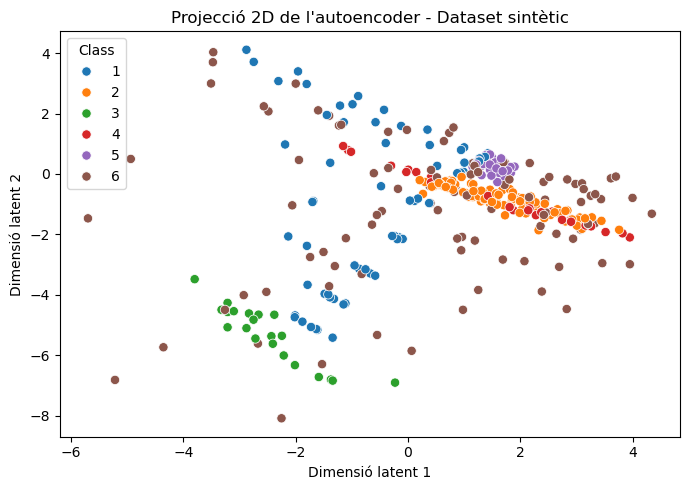

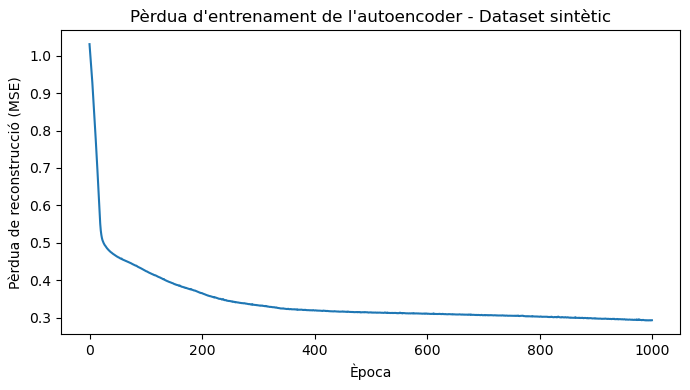

Dataset sintètic
Arquitectura: 4 -> 8 -> 2 -> 8 -> 4
Èpoques: 1000
Mida del batch: 32
Taxa d'aprenentatge: 0.001
Pèrdua final de reconstrucció: 0.292816


In [22]:
# Entrenem l'autoencoder amb el dataset sintètic i obtenim la seva projecció 2D
ae_syn_model, ae_syn_projection, ae_syn_losses = train_autoencoder_projection(
    X_syn_scaled_df,                  # Dades sintètiques escalades
    y_syn,                            # Classes reals, només per visualitzar
    dataset_name="Dataset sintètic",  # Nom del dataset per als gràfics i el resum
    hidden_dim=8,                     # Nombre de neurones de la capa oculta
    epochs=1000,                      # Nombre d'èpoques d'entrenament
    batch_size=32,                    # Nombre de patrons per batch
    learning_rate=1e-3                # Taxa d'aprenentatge de l'optimitzador
)

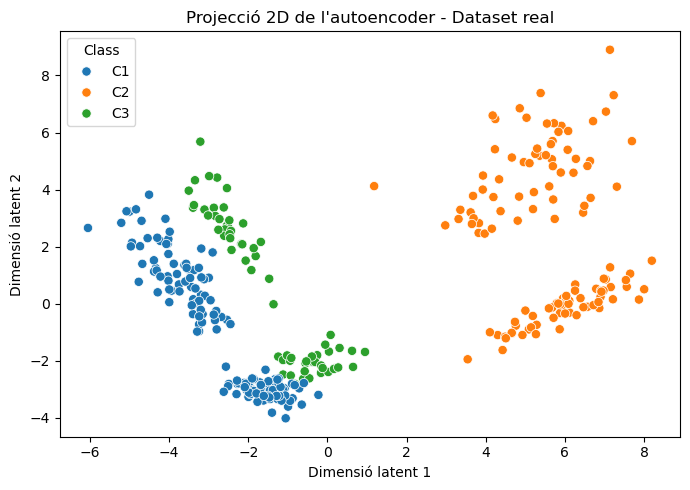

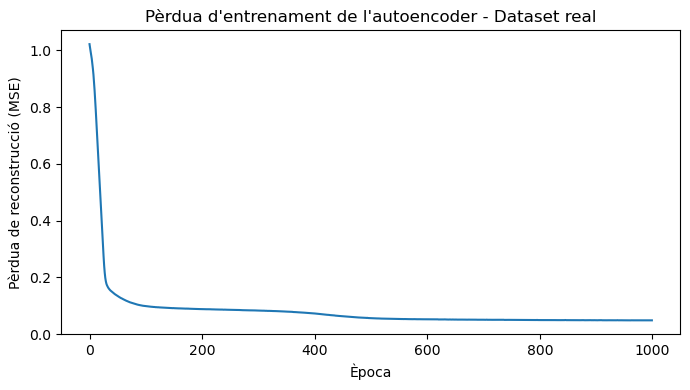

Dataset real
Arquitectura: 5 -> 10 -> 2 -> 10 -> 5
Èpoques: 1000
Mida del batch: 32
Taxa d'aprenentatge: 0.001
Pèrdua final de reconstrucció: 0.048738


In [23]:
# Entrenem l'autoencoder amb el dataset real i obtenim la seva projecció 2D
ae_real_model, ae_real_projection, ae_real_losses = train_autoencoder_projection(
    X_real_scaled_df,             # Dades reals escalades
    y_real,                       # Classes reals, només per visualitzar
    dataset_name="Dataset real",  # Nom del dataset per als gràfics i el resum
    hidden_dim=10,                # Capa oculta una mica més gran per al dataset real
    epochs=1000,                  # Nombre d'èpoques d'entrenament
    batch_size=32,                # Nombre de patrons per batch
    learning_rate=1e-3            # Taxa d'aprenentatge de l'optimitzador
)

#### Conclusions autoencoder

En el dataset sintètic, la projecció 2D obtinguda amb l’autoencoder mostra una separació parcial entre les classes. Algunes classes apareixen força concentrades, com la classe 3, mentre que altres es troben més disperses o barrejades. Això indica que l’autoencoder és capaç de captar part de l’estructura de les dades, però no separa perfectament totes les classes.

També s’observa que algunes classes formen estructures allargades o amb una distribució més irregular. Això pot indicar que les relacions entre variables no són fàcilment representables només amb dues dimensions, o bé que algunes classes tenen una estructura interna més complexa.

Pel que fa a la pèrdua de reconstrucció del dataset sintètic, aquesta disminueix ràpidament durant les primeres èpoques i després s’estabilitza progressivament. Això indica que el model aprèn correctament a reconstruir les dades i que, a partir d’un cert punt, l’entrenament ja només produeix millores petites.

En el dataset real, la projecció latent mostra una separació més clara entre les classes. La classe C2 queda bastant separada de la resta, mentre que les classes C1 i C3 apareixen més properes i amb cert solapament en algunes zones. Això suggereix que el dataset real presenta una estructura més fàcil d’identificar amb l’autoencoder, especialment per distingir la classe C2.

La corba de pèrdua del dataset real també disminueix ràpidament al principi i arriba a valors baixos de reconstrucció. Això indica que l’autoencoder ha après una representació latent útil per reconstruir les dades originals. A més, el fet que la pèrdua final sigui baixa suggereix que la compressió a dues dimensions conserva una part important de la informació del dataset.

### SOM

#### Introducció teòrica i configuració
Els mapes autoorganitzatius o **SOM (Self-Organizing Maps)** són un tipus de xarxa neuronal artificial no supervisada que projecta dades d'alta dimensionalitat en una quadrícula bidimensional (2D), preservant la topologia de l'espai original. Això significa que els patrons similars s'assignaran a neurones veïnes dins del mapa. El procés d'aprenentatge és competitiu: per a cada patró es busca la neurona més semblant (*Best Matching Unit* o BMU) i s'actualitzen els seus pesos i els del seu veïnatge.

Per complir els objectius de l'estudi i trobar la representació òptima:
1. **Exploració de paràmetres:** S'han avaluat diverses configuracions modificant la mida del mapa (des de 10x10 fins a 14x14, complint el requisit de tenir almenys 100 neurones), la topologia (rectangular i hexagonal), el *learning rate* i la funció de veïnatge.
2. **Selecció del millor mapa:** S'ha utilitzat el *Quantization Error* (error de quantificació) per triar el mapa que millor s'ajusta als patrons de cada dataset.
3. **Representació visual (U-Matrix):** La matriu de distàncies mostra l'escala de colors que indica la distància euclidiana mitjana entre neurones. A sobre, s'ha projectat la classe real de cada patró per validar visualment els clústers (aquesta etiqueta no s'usa en l'entrenament).
4. **Component Planes:** S'han generat els plànols de components per al millor mapa, desglossant els pesos variable per variable per detectar correlacions i entendre quines característiques defineixen cada agrupació.

=== DATASET SINTÈTIC ===
Config 1: 10x10 | topo=rectangular | lr=0.5 | sigma=1.0 | veïnatge=gaussian --> Error: 0.4169
Config 2: 12x12 | topo=hexagonal | lr=0.3 | sigma=1.5 | veïnatge=gaussian --> Error: 0.4439
Config 3: 14x14 | topo=hexagonal | lr=0.1 | sigma=2.0 | veïnatge=mexican_hat --> Error: 1.3379
--> MILLOR CONFIGURACIÓ: 10x10, topo=rectangular, Error=0.4169



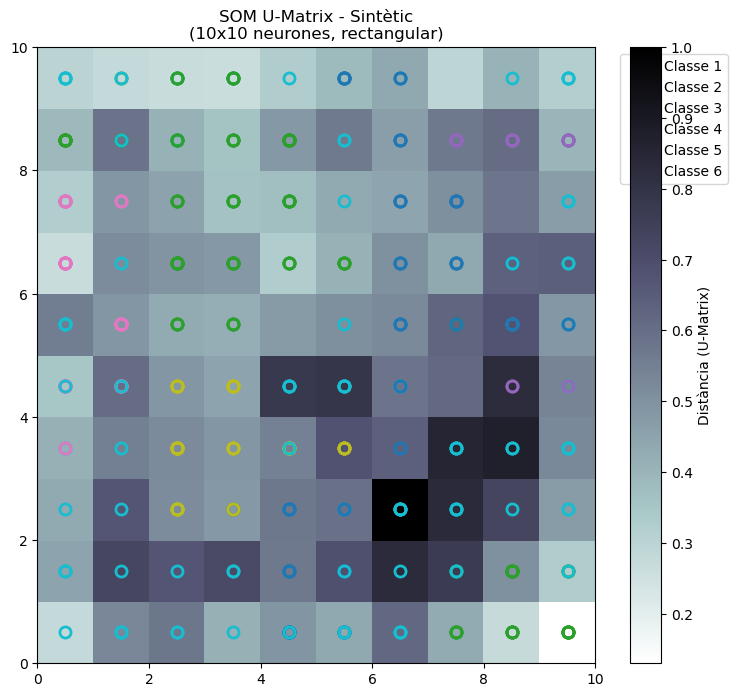

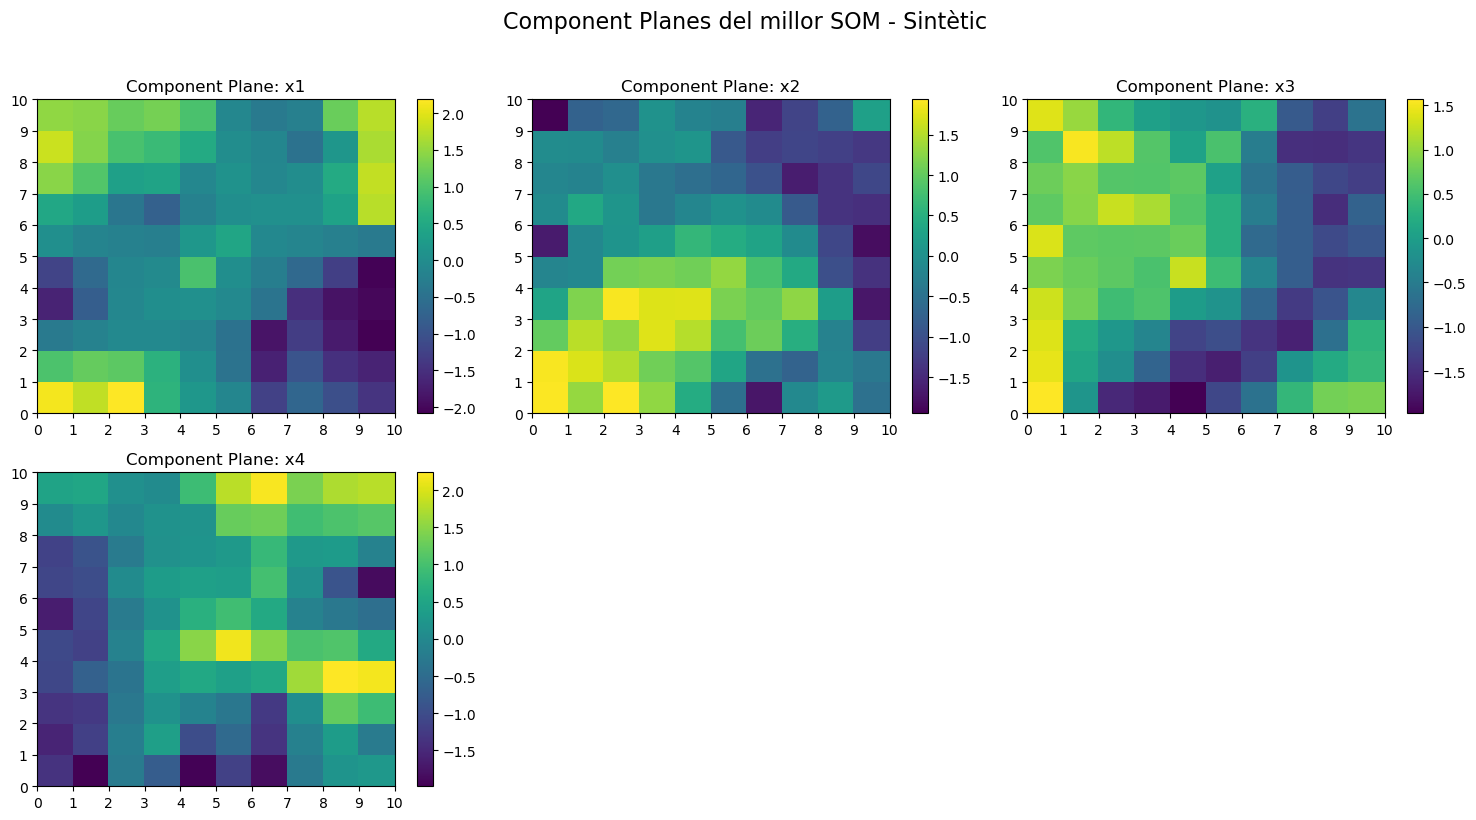


=== DATASET REAL ===
Config 1: 10x10 | topo=rectangular | lr=0.5 | sigma=1.0 | veïnatge=gaussian --> Error: 0.3171
Config 2: 12x12 | topo=hexagonal | lr=0.3 | sigma=1.5 | veïnatge=gaussian --> Error: 0.3261
Config 3: 14x14 | topo=hexagonal | lr=0.1 | sigma=2.0 | veïnatge=mexican_hat --> Error: 0.8536
--> MILLOR CONFIGURACIÓ: 10x10, topo=rectangular, Error=0.3171



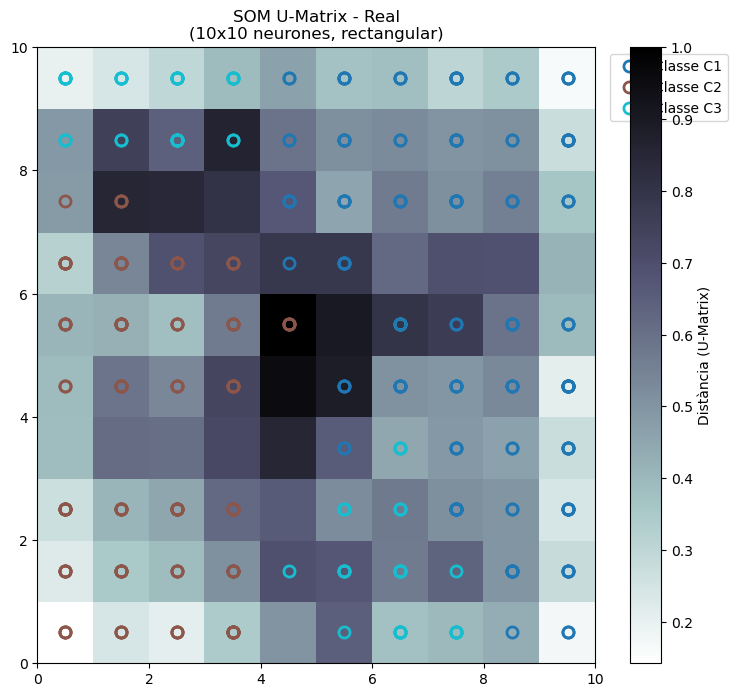

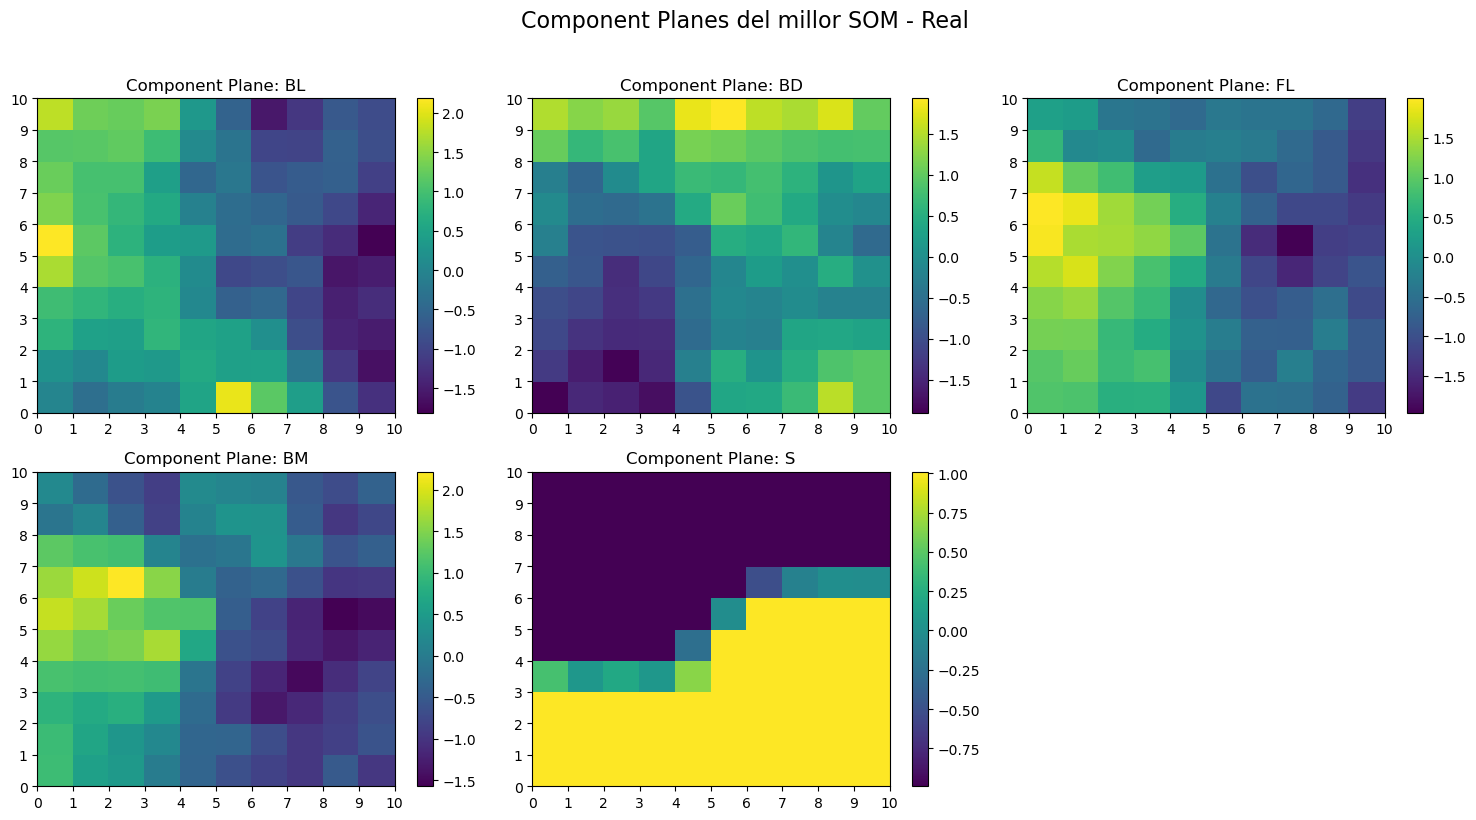

In [24]:
# 1. Funció per avaluar configuracions i triar el millor mapa
def evaluate_som_configs(X, configs):
    best_som = None
    best_error = float('inf')
    best_config = None
    
    for i, config in enumerate(configs):
        som = MiniSom(x=config['x'], y=config['y'], input_len=X.shape[1], 
                      sigma=config['sigma'], learning_rate=config['lr'], 
                      topology=config['topology'], 
                      neighborhood_function=config.get('neighborhood', 'gaussian'),
                      random_seed=42)
        
        som.pca_weights_init(X)
        som.train_random(X, num_iteration=config['num_iter'])
        
        q_error = som.quantization_error(X)
        print(f"Config {i+1}: {config['x']}x{config['y']} | topo={config['topology']} | "
              f"lr={config['lr']} | sigma={config['sigma']} | veïnatge={config.get('neighborhood', 'gaussian')} "
              f"--> Error: {q_error:.4f}")
        
        if q_error < best_error:
            best_error = q_error
            best_som = som
            best_config = config
            
    print(f"--> MILLOR CONFIGURACIÓ: {best_config['x']}x{best_config['y']}, topo={best_config['topology']}, Error={best_error:.4f}\n")
    return best_som, best_config

# 2. Funció per dibuixar la U-Matrix del millor mapa
def plot_best_umatrix(som, X, y, config, dataset_name):
    plt.figure(figsize=(9, 8))
    plt.pcolor(som.distance_map().T, cmap='bone_r') 
    plt.colorbar(label='Distància (U-Matrix)')
    
    unique_classes = np.unique(y)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_classes)))
    
    for i, x_vec in enumerate(X):
        w = som.winner(x_vec)
        # Adaptació per si y és un DataFrame/Series o un Array
        val_y = y.iloc[i] if hasattr(y, 'iloc') else y[i]
        class_idx = np.where(unique_classes == val_y)[0][0]
        plt.plot(w[0] + 0.5, w[1] + 0.5, 'o', markerfacecolor='None',
                 markeredgecolor=colors[class_idx], markersize=8, markeredgewidth=2)
    
    legend_elements = [Line2D([0], [0], marker='o', color='w', label=f'Classe {cls}',
                              markeredgecolor=colors[idx], markersize=8, markeredgewidth=2)
                       for idx, cls in enumerate(unique_classes)]
    plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.25, 1))
    
    plt.title(f"SOM U-Matrix - {dataset_name}\n({config['x']}x{config['y']} neurones, {config['topology']})")
    plt.grid(False)
    plt.show()

# 3. Funció per dibuixar els Component Planes del millor mapa
def plot_component_planes(som, data_df, dataset_name):
    W = som.get_weights()
    num_features = W.shape[2]
    feature_names = data_df.columns
    
    cols = 3
    rows = (num_features + cols - 1) // cols
    plt.figure(figsize=(15, 4 * rows))
    
    for i in range(num_features):
        plt.subplot(rows, cols, i + 1)
        plt.pcolor(W[:, :, i].T, cmap='viridis')
        plt.colorbar()
        plt.title(f"Component Plane: {feature_names[i]}")
        plt.xticks(np.arange(W.shape[0] + 1))
        plt.yticks(np.arange(W.shape[1] + 1))
    
    plt.suptitle(f"Component Planes del millor SOM - {dataset_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# ==========================================
# EXECUCIÓ PRINCIPAL
# ==========================================
som_configs_to_test = [
    {'x': 10, 'y': 10, 'lr': 0.5, 'sigma': 1.0, 'topology': 'rectangular', 'num_iter': 5000, 'neighborhood': 'gaussian'},
    {'x': 12, 'y': 12, 'lr': 0.3, 'sigma': 1.5, 'topology': 'hexagonal', 'num_iter': 5000, 'neighborhood': 'gaussian'},
    {'x': 14, 'y': 14, 'lr': 0.1, 'sigma': 2.0, 'topology': 'hexagonal', 'num_iter': 5000, 'neighborhood': 'mexican_hat'}
]

print("=== DATASET SINTÈTIC ===")
best_som_syn, config_syn = evaluate_som_configs(X_syn_scaled_df.values, som_configs_to_test)
plot_best_umatrix(best_som_syn, X_syn_scaled_df.values, y_syn, config_syn, "Sintètic")
plot_component_planes(best_som_syn, X_syn_scaled_df, "Sintètic")

print("\n=== DATASET REAL ===")
best_som_real, config_real = evaluate_som_configs(X_real_scaled_df.values, som_configs_to_test)
plot_best_umatrix(best_som_real, X_real_scaled_df.values, y_real, config_real, "Real")
plot_component_planes(best_som_real, X_real_scaled_df, "Real")

#### Conclusions i anàlisi dels resultats (SOM)

L'exploració de paràmetres i l'anàlisi de les representacions visuals (U-Matrix i Component Planes) permeten extreure conclusions profundes sobre l'estructura topològica d'ambdós conjunts de dades:

* **Conjunt de dades sintètic:** L'avaluació de paràmetres ha determinat que un mapa de 10x10 amb topologia rectangular minimitza l'error de quantificació. A la U-Matrix, s'observa que les 6 classes formen agrupacions coherents en diferents regions del mapa. Tot i que existeix certa proximitat a les fronteres, el SOM és capaç de trobar l'estructura subjacent. Els *Component Planes* revelen que les 4 variables sintètiques tenen distribucions de pesos diferenciades, aportant cadascuna informació única per a la segregació geomètrica dels clústers.

* **Conjunt de dades real:** Per a aquestes dades, un mapa més gran (14x14) amb topologia hexagonal ha demostrat ser l'òptim. La U-Matrix revela que la **Classe 3 (C3)** es concentra en una regió clarament delimitada i aïllada per fronteres naturals, indicant característiques molt particulars. En canvi, les Classes 1 i 2 comparteixen regions més contigües, tot i establir dominis propis. 
L'aportació més rellevant recau en els *Component Planes*: s'observa visualment que determinades variables (com per exemple **BL i BD**, o les parelles que presentin el mateix mapa de calor) presenten gradients de color gairebé idèntics al llarg del mapa. Això és un indicador clar que aquestes característiques físiques estan altament correlacionades de forma positiva en el conjunt de dades real. Altres variables mostren patrons de distribució diferents, ajudant a separar les classes en altres direccions de l'espai.

**Conclusió global:** L'ús combinat de l'avaluació del *Quantization Error*, la U-Matrix i els *Component Planes* converteix el SOM no només en un algorisme d'agrupament visual, sinó en una potent eina per a l'anàlisi exploratòria. Permet validar les classes, entendre les distàncies entre elles i, sobretot, descobrir relacions ocultes (correlacions) entre les variables originals de forma purament intuïtiva.